# Clustering comparison: K-Means vs DBSCAN vs Agglomerative

Same scaled feature set (`recency`, `frequency`, `monetary`, `category_diversity`, `avg_basket_size`, `is_international`) for all three, so the comparison is fair.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

plt.style.use("seaborn-v0_8-whitegrid")

X = pd.read_parquet("../data/processed/rfm_features_scaled.parquet")
print(X.shape)
X.head()

(5852, 6)


,recency,frequency,monetary,category_diversity,avg_basket_size,is_international
Customer_ID,,,,,,
12346,0.603391,-0.199156,3.204014,-0.490955,-0.706897,-0.311629
12347,-0.950628,0.804865,1.311218,0.376061,0.503507,3.208940
12348,-0.600494,0.302855,0.427928,-0.499539,-0.661859,3.208940
12349,-0.869090,-0.199156,1.003366,0.470489,1.839500,3.208940
12350,0.526649,-1.057348,-0.819150,-0.568214,-0.308481,3.208940


## 1. K-Means: elbow + silhouette to pick k

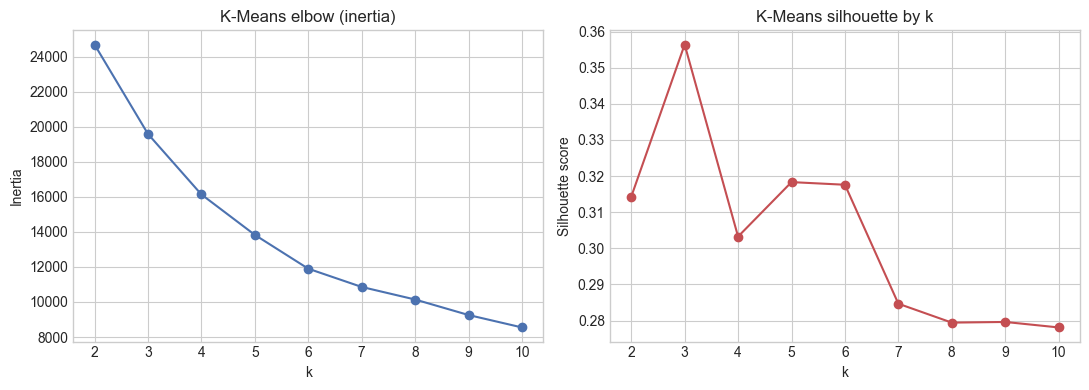

k=2: silhouette=0.3143, inertia=24704.9
k=3: silhouette=0.3564, inertia=19599.3
k=4: silhouette=0.3032, inertia=16143.1
k=5: silhouette=0.3183, inertia=13835.1
k=6: silhouette=0.3176, inertia=11902.7
k=7: silhouette=0.2847, inertia=10860.3
k=8: silhouette=0.2794, inertia=10142.0
k=9: silhouette=0.2796, inertia=9256.9
k=10: silhouette=0.2781, inertia=8546.8


In [2]:
k_range = range(2, 11)
inertias, sils = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(k_range), inertias, marker="o", color="#4c72b0")
axes[0].set_title("K-Means elbow (inertia)")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), sils, marker="o", color="#c44e52")
axes[1].set_title("K-Means silhouette by k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette score")
plt.tight_layout()
plt.show()

for k, s, i in zip(k_range, sils, inertias):
    print(f"k={k}: silhouette={s:.4f}, inertia={i:.1f}")

Silhouette peaks at **k=3** (0.356). The elbow in inertia is soft (no sharp knee), which is common for RFM data since it's inherently continuous, not naturally globular clusters, this is itself a finding worth noting for the writeup: K-Means is imposing spherical clusters on data that may not have them.

In [3]:
KM_K = 3
kmeans_final = KMeans(n_clusters=KM_K, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X)
pd.Series(kmeans_labels).value_counts().sort_index()

0     513
1    3301
2    2038
Name: count, dtype: int64

## 2. DBSCAN: k-distance plot to pick eps

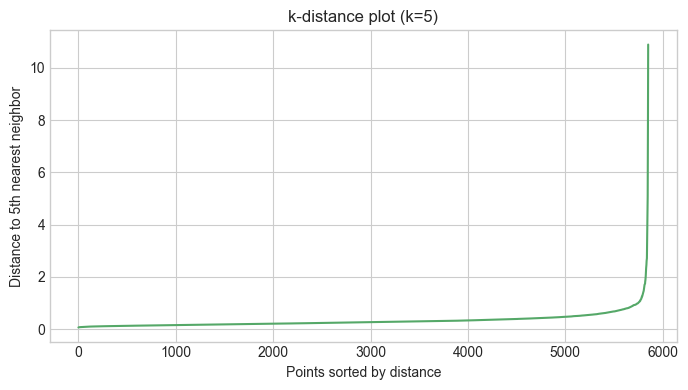

p50: 0.260
p75: 0.375
p90: 0.553
p95: 0.726
p97: 0.864
p99: 1.286


In [4]:
MIN_SAMPLES = 5
nn = NearestNeighbors(n_neighbors=MIN_SAMPLES)
nn.fit(X)
distances, _ = nn.kneighbors(X)
k_distances = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_distances, color="#55a868")
ax.set_title(f"k-distance plot (k={MIN_SAMPLES})")
ax.set_xlabel("Points sorted by distance")
ax.set_ylabel(f"Distance to {MIN_SAMPLES}th nearest neighbor")
plt.tight_layout()
plt.show()

for p in [50, 75, 90, 95, 97, 99]:
    print(f"p{p}: {np.percentile(k_distances, p):.3f}")

The knee sits roughly where the curve starts climbing steeply — around the p90-p95 range here. Trying a spread of eps values around that instead of picking one blindly:

In [5]:
trial_rows = []
for eps in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0]:
    db = DBSCAN(eps=eps, min_samples=MIN_SAMPLES)
    labels = db.fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int((labels == -1).sum())
    if n_clusters >= 2:
        mask = labels != -1
        sil = silhouette_score(X[mask], labels[mask]) if mask.sum() > 1 else np.nan
    else:
        sil = np.nan
    trial_rows.append({"eps": eps, "n_clusters": n_clusters, "n_noise": n_noise,
                        "pct_noise": n_noise / len(X) * 100, "silhouette_non_noise": sil})

pd.DataFrame(trial_rows)

,eps,n_clusters,n_noise,pct_noise,silhouette_non_noise
0,0.3,32,1693,28.930280,-0.067891
1,0.4,21,876,14.969241,-0.107021
2,0.5,14,474,8.099795,0.142532
3,0.6,8,307,5.246070,0.298763
4,0.7,6,190,3.246753,0.336911
5,0.8,7,108,1.845523,0.324349
6,1.0,3,66,1.127820,0.405770


`eps=0.7` gives a reasonable balance: 6 clusters, only 3.2% flagged as noise/outliers, and the best silhouette (0.337) among the multi-cluster options. `eps=1.0` scores higher but collapses down to 3 clusters with almost no noise — it stops behaving like a density-based outlier detector at that point, which defeats the purpose of using DBSCAN here.

In [6]:
DBSCAN_EPS = 0.7
dbscan_final = DBSCAN(eps=DBSCAN_EPS, min_samples=MIN_SAMPLES)
dbscan_labels = dbscan_final.fit_predict(X)
pd.Series(dbscan_labels).value_counts().sort_index()

-1     190
 0     447
 1       6
 2    5191
 3       6
 4       7
 5       5
Name: count, dtype: int64

## 3. Agglomerative (ward linkage): dendrogram to pick cut height

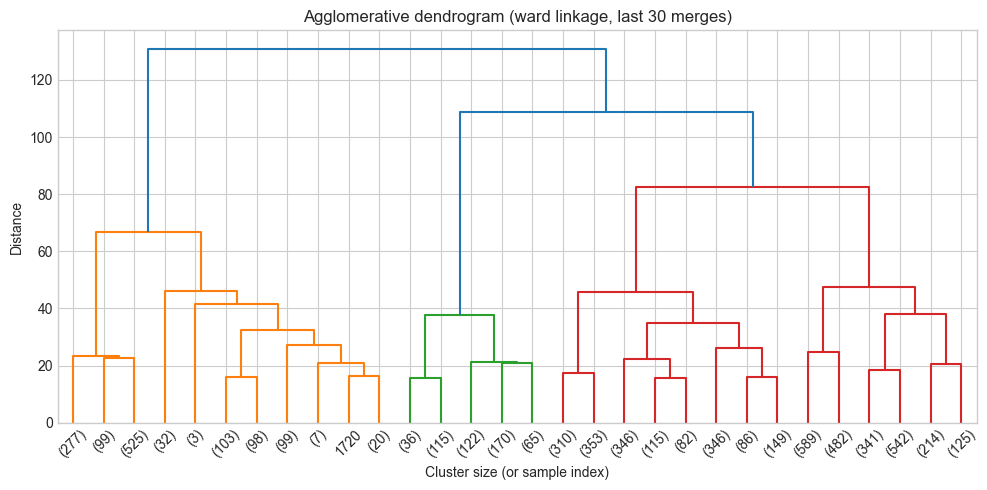

In [7]:
Z = linkage(X, method="ward")

fig, ax = plt.subplots(figsize=(10, 5))
dendrogram(Z, truncate_mode="lastp", p=30, ax=ax)
ax.set_title("Agglomerative dendrogram (ward linkage, last 30 merges)")
ax.set_xlabel("Cluster size (or sample index)")
ax.set_ylabel("Distance")
plt.tight_layout()
plt.show()

In [8]:
agglo_rows = []
for k in range(2, 8):
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = agg.fit_predict(X)
    agglo_rows.append({"k": k, "silhouette": silhouette_score(X, labels),
                        "davies_bouldin": davies_bouldin_score(X, labels)})

pd.DataFrame(agglo_rows)

,k,silhouette,davies_bouldin
0,2,0.314526,1.238061
1,3,0.374845,1.047680
2,4,0.275357,1.174815
3,5,0.266457,1.192825
4,6,0.214071,1.204881
5,7,0.219901,1.119276


Agglomerative also peaks at **k=3** (silhouette 0.375, its best score) — matching K-Means. That's a useful cross-check: two different algorithms agree the macro-structure is 3 groups, before DBSCAN adds the outlier layer on top.

In [9]:
AGGLO_K = 3
agglo_final = AgglomerativeClustering(n_clusters=AGGLO_K, linkage="ward")
agglo_labels = agglo_final.fit_predict(X)
pd.Series(agglo_labels).value_counts().sort_index()

0    4080
1    1264
2     508
Name: count, dtype: int64

## 4. Comparison table

In [10]:
def summarize(name, labels, X):
    labels = np.asarray(labels)
    has_noise = -1 in labels
    n_clusters = len(set(labels)) - (1 if has_noise else 0)
    n_noise = int((labels == -1).sum()) if has_noise else 0
    mask = labels != -1 if has_noise else np.ones(len(labels), dtype=bool)
    sil = silhouette_score(X[mask], labels[mask])
    db_idx = davies_bouldin_score(X[mask], labels[mask])
    return {
        "algorithm": name,
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "pct_noise": round(n_noise / len(labels) * 100, 2),
        "silhouette": round(sil, 4),
        "davies_bouldin": round(db_idx, 4),
    }

comparison = pd.DataFrame([
    summarize("K-Means (k=3)", kmeans_labels, X.values),
    summarize("DBSCAN (eps=0.7)", dbscan_labels, X.values),
    summarize("Agglomerative (k=3, ward)", agglo_labels, X.values),
])
comparison

,algorithm,n_clusters,n_noise,pct_noise,silhouette,davies_bouldin
0,K-Means (k=3),3,0,0.00,0.3564,1.0512
1,DBSCAN (eps=0.7),6,190,3.25,0.3369,0.6927
2,"Agglomerative (k=3, ward)",3,0,0.00,0.3748,1.0477


## 5. Save labels for the persona/visualization notebook

In [11]:
labels_df = pd.DataFrame({
    "kmeans": kmeans_labels,
    "dbscan": dbscan_labels,
    "agglomerative": agglo_labels,
}, index=X.index)

OUT_PATH = Path("../data/processed/cluster_labels.parquet")
labels_df.to_parquet(OUT_PATH)
print(f"Saved labels for {len(labels_df)} customers to {OUT_PATH}")

Saved labels for 5852 customers to ..\data\processed\cluster_labels.parquet
